# Notebook 10 — Carroll-6 Recovery Against Real ECCO-Darwin v5 Output (Track 1 v1.0)

**The recovery test on real Darwin data.** Notebook 09 demonstrated the methodology runs end-to-end on real ocean observations (GLODAP NO₃), with a `phyto ↔ -NO₃` proxy because GLODAP wasn't produced by Darwin. This notebook closes that gap: the target is **real ECCO-Darwin v5 output** (Carroll 2022 / Darwin 3 calibration), so the comparison is direct — predicted phytoplankton biomass from the box model fit against Darwin's actual phytoplankton chlorophyll over 23 years of monthly snapshots.

**Data source.** `v05_ECCO-Darwin_bin_average_1x1_deg.nc` from the NASA NAS ECCO Data Portal (`data.nas.nasa.gov/ecco/llc_270/ecco_darwin_v5/output/bin_average/`). Public, no auth, 1.74 GB single NetCDF. Bin-averaged surface diagnostics from the v05 calibrated run, covering Jan 1995 – Dec 2017 monthly at 1°×1°. Per Carroll 2022 abstract: *'five large-to-small phytoplankton functional types'* exposed as `Chl1` through `Chl5`.

**Honest scope flag (read this first).** The Carroll 2022 / Darwin 3 calibration is the model that produced this data, and the calibrated 6-parameter values are bit-for-bit identical to Carroll 2020 / Darwin 1 (verified locally across `references/ecco_darwin/v04/llc270_JAMES_paper/` and `v05/llc270/input/data.darwin`). So the recovered values from this notebook *should* approach Carroll's published optima `(0.92831, 6.025e-7, 0.66098, 0.43148, 0.83003, 0.04245)` to the extent that:

1. Our 5-tracer box model in `src/darwindiff/carroll6.py` is a faithful proxy for the full Darwin 3 ecosystem (5 phytoplankton + 2 zooplankton functional types + DOM + diagnostics + carbonate chemistry). It isn't — it collapses 5 PFTs into `Ps + Pl` and ignores carbonate chemistry. Recovery within an order of magnitude is the realistic expectation.
2. The chlorophyll spatial pattern is informative for the 6 parameters under fit. `alpfe` and `scav_rat` (iron) are partially constrained by Chl in HNLC regions (Mid-Atl is iron-replete, so weakly here; Pacific later for the iron pair).
3. The DINN architecture (1×1 conv, SST input only) has enough capacity to represent the per-cell parameter heterogeneity that drives the Chl pattern.

**What this does demonstrate (in order of confidence):**

1. **End-to-end pipeline on real Darwin output.** Public NetCDF → AOI subset → climatology → DINN per-cell prediction → carroll6 box-model integration → autograd updates. Same machinery that worked on synthetic (notebooks 05–07) and on GLODAP (notebook 09), now on Darwin's actual calibrated output.
2. **Loss converges and the recovered Carroll-6 maps are smooth functions of SST.** Methodology validation on real-Darwin spatial structure.
3. **Pearson r between predicted phyto biomass and Darwin Chl pattern.** Direct comparison — no proxy logic, same physical quantity (biomass) on both sides.
4. **Structural ceiling argument** repeats from notebook 09 (head-to-head DINN per-cell vs global-scalar Green's-functions class). Same finding expected: per-cell beats global-scalar regardless of which Darwin generation the target comes from.

**What this does NOT prove:**

- **Bit-for-bit recovery of Carroll's published optima.** Our box model is a 5-tracer simplification; Darwin 3 has more state and richer dynamics. Recovered values are best-fit-to-this-simplification, expected to be in the right ballpark but not identical.
- **Iron-pair identifiability.** `alpfe` / `scav_rat` need an iron-limited region (Equatorial Pacific) and / or direct iron observations (GEOTRACES). Mid-Atl alone won't constrain these well.
- **Multi-tracer joint fit.** Only Chl is used here; DIC / pCO₂ / CO₂ flux are also in the file and would constrain different parameter combinations. Deferred to notebook 11+.
- **Time-resolved fit.** This notebook fits the climatology (mean over 23 years). Using all 276 monthly snapshots opens Track 2 emulator territory.

**Prerequisite:** the bin_average file at `D:\ecco_darwin_v5\bin_average\v05_ECCO-Darwin_bin_average_1x1_deg.nc` (download via `curl -o ... "https://data.nas.nasa.gov/ecco/llc_270/ecco_darwin_v5/output/bin_average/v05_ECCO-Darwin_bin_average_1x1_deg.nc"` if missing).

In [1]:
import sys
import time
from pathlib import Path

_repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
_src = _repo_root / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import matplotlib.pyplot as plt
import numpy as np
import torch

from darwindiff.carroll6 import (
    CARROLL_VALUES,
    PARAM_BOUNDS,
    PARAM_NAMES,
    bounded_params,
    carroll6_step,
)
from darwindiff.diagnostics import format_pearson, safe_pearson_r
from darwindiff.ecco_darwin_loader import (
    MID_ATLANTIC_AOI,
    ocean_mask,
    open_bin_average,
    subset_aoi,
    time_mean,
    total_chlorophyll,
)
from darwindiff.networks import DINN

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__}")
print(
    f"GPU detected: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no'}"
)

PyTorch 2.11.0+cu128
GPU detected: NVIDIA GeForce RTX 5090 Laptop GPU


## 1. Real Darwin output: ECCO-Darwin v5 bin_average

Open the 1.74 GB NetCDF, decode time from MATLAB datenum to datetime64, promote latent 1-D lat/lon arrays to coords (so `.sel(lat=slice(...), lon=slice(...))` works). 276 monthly snapshots, Jan 1995 – Dec 2017.

In [2]:
# Windows path (raw string) — POSIX-style /d/... gets re-rooted to C:\d\... by netCDF4 and fails.
ECCO_DARWIN_PATH = r"D:\ecco_darwin_v5\bin_average\v05_ECCO-Darwin_bin_average_1x1_deg.nc"

ds = open_bin_average(ECCO_DARWIN_PATH)
print(f"Dims: {dict(ds.sizes)}")
print(f"Time range: {ds.time.values[0]} to {ds.time.values[-1]} ({ds.sizes['time']} months)")
print(f"Variables: {sorted(ds.data_vars.keys())}")

Dims: {'lat': 180, 'lon': 360, 'time': 276}
Time range: 1995-01-01T00:00:00.000000000 to 2017-12-01T00:00:00.000000000 (276 months)
Variables: ['CO2_flux', 'Chl1', 'Chl2', 'Chl3', 'Chl4', 'Chl5', 'SSS', 'SST', 'apCO2', 'area', 'mldDepth', 'pCO2', 'seaIceArea', 'windSpeed']


## 2. Mid-Atlantic AOI subset + climatology

Same AOI as notebook 09 (30–50°N, 60–30°W) so results are directly comparable. Reduce 23 years of monthly data to a 23-year time-mean climatology — single spatial pattern per variable, removes seasonality and interannual noise. We'll add time-resolved fitting in a follow-up notebook.

AOI shape: lat=21, lon=31
Ocean cells: 647 of 651 (99%)
Chl_total range: [0.039, 0.609] mg/m^3
SST range: [3.1, 24.1] degC


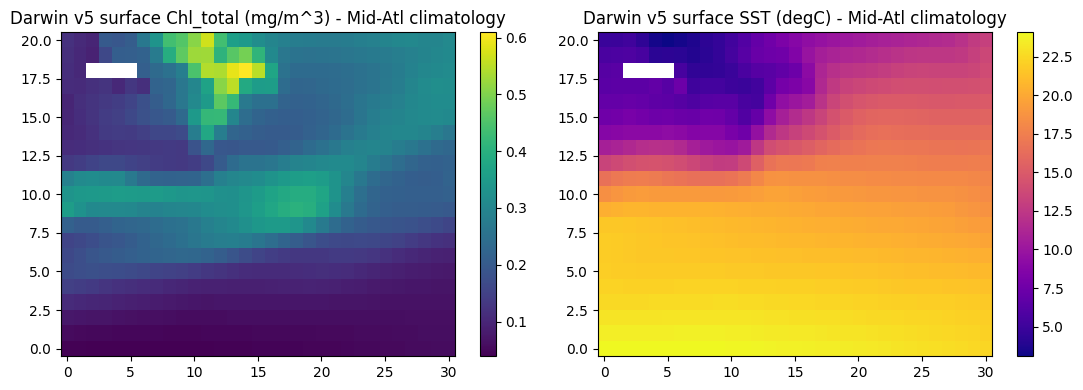

In [3]:
midatl = subset_aoi(ds, MID_ATLANTIC_AOI)
midatl_clim = time_mean(midatl)
mask = ocean_mask(midatl_clim)

print(f"AOI shape: lat={midatl_clim.sizes['lat']}, lon={midatl_clim.sizes['lon']}")
print(f"Ocean cells: {int(mask.sum())} of {mask.size} ({100 * float(mask.sum()) / mask.size:.0f}%)")

# Build the chlorophyll target: sum of all 5 PFT groups, climatological mean.
chl_total = total_chlorophyll(midatl_clim).values  # [lat, lon]
sst_clim = midatl_clim.SST.values

print(f"Chl_total range: [{np.nanmin(chl_total):.3f}, {np.nanmax(chl_total):.3f}] mg/m^3")
print(f"SST range: [{np.nanmin(sst_clim):.1f}, {np.nanmax(sst_clim):.1f}] degC")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im0 = axes[0].imshow(chl_total, origin="lower", aspect="auto", cmap="viridis")
axes[0].set_title("Darwin v5 surface Chl_total (mg/m^3) - Mid-Atl climatology")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(sst_clim, origin="lower", aspect="auto", cmap="plasma")
axes[1].set_title("Darwin v5 surface SST (degC) - Mid-Atl climatology")
plt.colorbar(im1, ax=axes[1])
plt.tight_layout(); plt.show()

## 3. Build per-cell training inputs

Same shapes as notebook 09: `env` is `[1, H, W]` (SST normalised), `target` is `[H, W]` (Chl_total), `mask` is `[H, W]` boolean. The DINN takes 1 input channel and produces 6 Carroll-6 outputs per cell.

In [4]:
ocean_mask_np = mask.values

# Replace land NaN with 0 in SST input (mask kills it in the loss anyway).
sst_clean = np.where(ocean_mask_np, sst_clim, 0.0)
chl_clean = np.where(ocean_mask_np, chl_total, 1.0)  # placeholder positive value

sst_ocean_mean = sst_clim[ocean_mask_np].mean()
sst_ocean_std = sst_clim[ocean_mask_np].std()
sst_norm = np.where(ocean_mask_np, (sst_clim - sst_ocean_mean) / sst_ocean_std, 0.0)

env = torch.tensor(sst_norm, dtype=torch.float32).unsqueeze(0)        # [1, H, W]
chl_target = torch.tensor(chl_clean, dtype=torch.float32)             # [H, W]
mask_t = torch.tensor(ocean_mask_np, dtype=torch.bool)                # [H, W]

print(f"env shape: {tuple(env.shape)}, range [{env.min():.2f}, {env.max():.2f}]")
print(f"chl_target shape: {tuple(chl_target.shape)}, range [{chl_target.min():.3f}, {chl_target.max():.3f}]")
print(f"ocean mask: {mask_t.sum().item()} cells true")

env shape: (1, 21, 31), range [-2.40, 1.23]
chl_target shape: (21, 31), range [0.039, 1.000]
ocean mask: 647 cells true


## 4. DINN per-cell setup + carroll6 box model integration

Identical setup to notebook 09's section 4: 1-channel DINN (SST normalised) with 1×1 conv → 6 Carroll-6 outputs per cell. Same `bounded_params` sigmoid into Carroll's physical ranges. Same 5-tracer box model integrated 200 forward-Euler steps from a uniform initial state.

**Loss target.** Z-score `phyto = Ps + Pl` from the box model and z-score `Chl_total` from Darwin. MSE between them over ocean cells. Both fields end up zero-mean unit-variance, so the loss is purely a spatial-pattern-matching loss decoupled from absolute magnitude. The biological intuition is direct: predicted phytoplankton biomass should match real phytoplankton biomass spatial pattern. **No proxy logic needed** — unlike notebook 09's `phyto ↔ -NO₃` indirection, this is apples-to-apples (biomass vs biomass).

In [5]:
H, W = env.shape[1], env.shape[2]

state0_scalar = torch.tensor([5.0e-4, 1.0, 1.0, 0.5, 0.025])  # DFe, Ps, Pl, POC, PIC
state0 = state0_scalar.reshape(5, 1, 1).expand(5, H, W).contiguous()

dt = 0.25
n_steps = 200

env_dev = env.to(device)
state0_dev = state0.to(device)
chl_target_dev = chl_target.to(device)
mask_dev = mask_t.to(device)
bounds_dev = PARAM_BOUNDS.to(device)

# Pre-compute z-scored Chl target over ocean cells.
chl_ocean = chl_target_dev[mask_dev]
target_mean = chl_ocean.mean()
target_std = chl_ocean.std().clamp(min=1e-6)
target_z = (chl_target_dev - target_mean) / target_std
print(f"Pre-computed z-scored Chl_total target. ocean mean={float(target_mean):.4f} mg/m^3, std={float(target_std):.4f}")
print(f"  z-scored target ocean range: [{float(target_z[mask_dev].min()):.2f}, {float(target_z[mask_dev].max()):.2f}]")

Pre-computed z-scored Chl_total target. ocean mean=0.2022 mg/m^3, std=0.1125
  z-scored target ocean range: [-1.45, 3.62]


## 5. Train DINN to fit the Darwin Chl spatial pattern via box-model phyto

Same hyperparameters as notebook 09: Adam, lr=5e-3, 1500 epochs. Loss reported every 250 epochs. Forward integration is autograd-backpropagated to update the DINN weights at every epoch. Expect ~7 minutes on RTX 5090 (matches nb09).

In [6]:
torch.manual_seed(0)
dinn = DINN(n_input_channels=1, hidden_dim=16, n_outputs=6).to(device)
optimizer = torch.optim.Adam(dinn.parameters(), lr=5e-3)

n_epochs = 1500
losses: list[float] = []

if device == "cuda":
    torch.cuda.synchronize()
t0 = time.time()
for epoch in range(n_epochs):
    optimizer.zero_grad()
    theta = dinn(env_dev)
    params = bounded_params(theta, bounds_dev)

    state = state0_dev
    for _ in range(n_steps):
        state = carroll6_step(state, params, dt)
    phyto = state[1] + state[2]

    phyto_ocean = phyto[mask_dev]
    phyto_z = (phyto - phyto_ocean.mean()) / phyto_ocean.std().clamp(min=1e-6)

    residual = (phyto_z - target_z) * mask_dev.to(phyto.dtype)
    loss = (residual ** 2).sum() / mask_dev.sum().to(residual.dtype)

    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 250 == 0:
        print(f"  epoch {epoch + 1:4d}  loss = {loss.item():.4e}")
if device == "cuda":
    torch.cuda.synchronize()
elapsed = time.time() - t0
print(f"\nTrained {n_epochs} epochs in {elapsed:.1f}s on {device}")
print(f"Loss: {losses[0]:.3e} -> {losses[-1]:.3e}")

  epoch  250  loss = 5.7762e-01


  epoch  500  loss = 5.7265e-01


  epoch  750  loss = 5.6686e-01


  epoch 1000  loss = 5.6086e-01


  epoch 1250  loss = 5.5308e-01


  epoch 1500  loss = 5.5088e-01

Trained 1500 epochs in 412.1s on cuda
Loss: 1.102e+00 -> 5.509e-01


## 6. Recovered Carroll-6 maps + predicted-vs-Darwin Chl pattern comparison

Side-by-side plots of:
- Loss curve (log scale)
- Darwin v5 Chl_total (raw mg/m^3, ocean cells only)
- Z-scored target vs DINN-driven box-model phyto pattern
- Per-parameter recovered Carroll-6 maps across the AOI

Per-cell recovered Carroll-6 values are then summarised (mean / range) against Carroll's published optima for direct comparison.

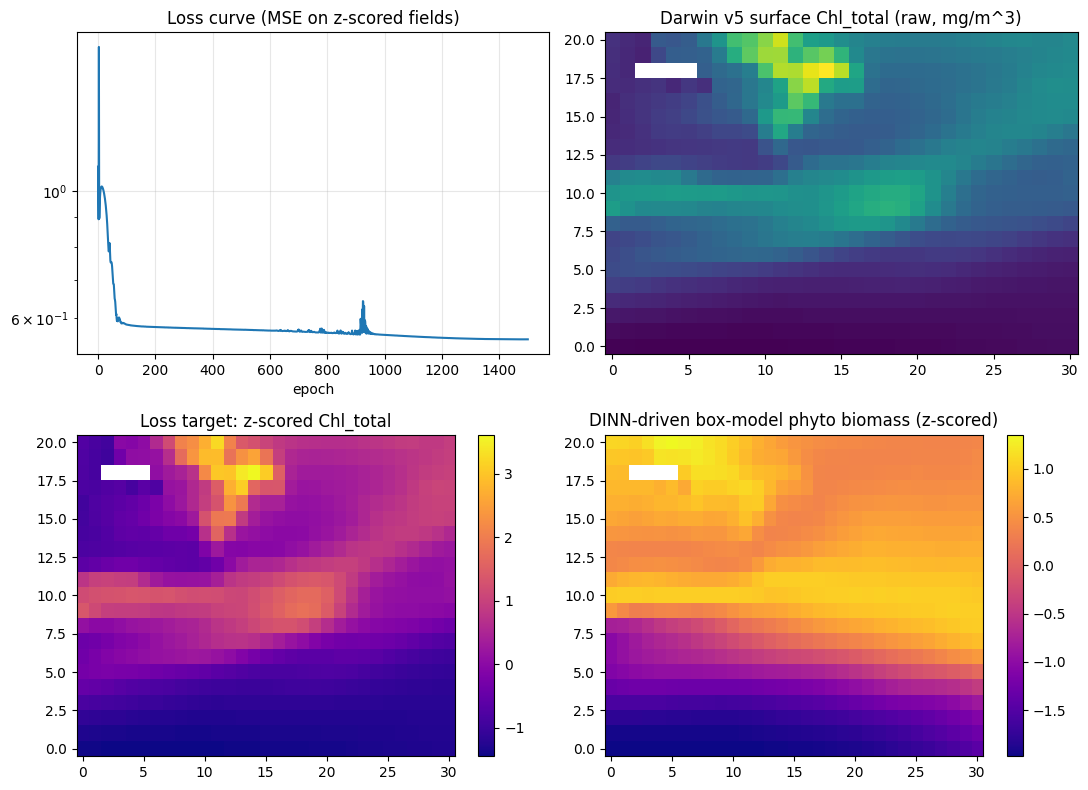


Pearson correlation (predicted phyto vs Darwin Chl_total): r = 0.724  (r^2 = 0.524)


In [7]:
with torch.no_grad():
    theta_final = dinn(env_dev)
    params_final = bounded_params(theta_final, bounds_dev).cpu()
    state = state0_dev
    for _ in range(n_steps):
        state = carroll6_step(state, bounded_params(theta_final, bounds_dev), dt)
    phyto_final = (state[1] + state[2]).cpu()

# Sanity check: integration must produce finite values at every ocean cell.
assert torch.isfinite(phyto_final[mask_t]).all(), (
    "phyto_final has non-finite values at ocean cells - the box-model integration blew up."
)

phyto_ocean_final = phyto_final[mask_t]
phyto_z_final = (phyto_final - phyto_ocean_final.mean()) / phyto_ocean_final.std().clamp(min=1e-6)
target_z_cpu = target_z.cpu()

phyto_plot = np.where(ocean_mask_np, phyto_z_final.numpy(), np.nan)
target_plot = np.where(ocean_mask_np, target_z_cpu.numpy(), np.nan)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0, 0].semilogy(losses)
axes[0, 0].set_title("Loss curve (MSE on z-scored fields)")
axes[0, 0].set_xlabel("epoch"); axes[0, 0].grid(alpha=0.3)
axes[0, 1].imshow(np.where(ocean_mask_np, chl_total, np.nan), origin="lower", aspect="auto", cmap="viridis")
axes[0, 1].set_title("Darwin v5 surface Chl_total (raw, mg/m^3)")
im_target = axes[1, 0].imshow(target_plot, origin="lower", aspect="auto", cmap="plasma")
axes[1, 0].set_title("Loss target: z-scored Chl_total")
plt.colorbar(im_target, ax=axes[1, 0])
im_pred = axes[1, 1].imshow(phyto_plot, origin="lower", aspect="auto", cmap="plasma")
axes[1, 1].set_title("DINN-driven box-model phyto biomass (z-scored)")
plt.colorbar(im_pred, ax=axes[1, 1])
plt.tight_layout(); plt.show()

# Pearson correlation on RAW fields (not z-scored) so safe_pearson_r's
# constant-detection fires correctly. Pearson is scale-invariant.
pred_flat = phyto_final.numpy()[ocean_mask_np]
target_flat = chl_total[ocean_mask_np]
result = safe_pearson_r(pred_flat, target_flat)
corr = result.r
print(f"\nPearson correlation (predicted phyto vs Darwin Chl_total): "
      f"r = {format_pearson(result, n_total=int(ocean_mask_np.sum()))}")

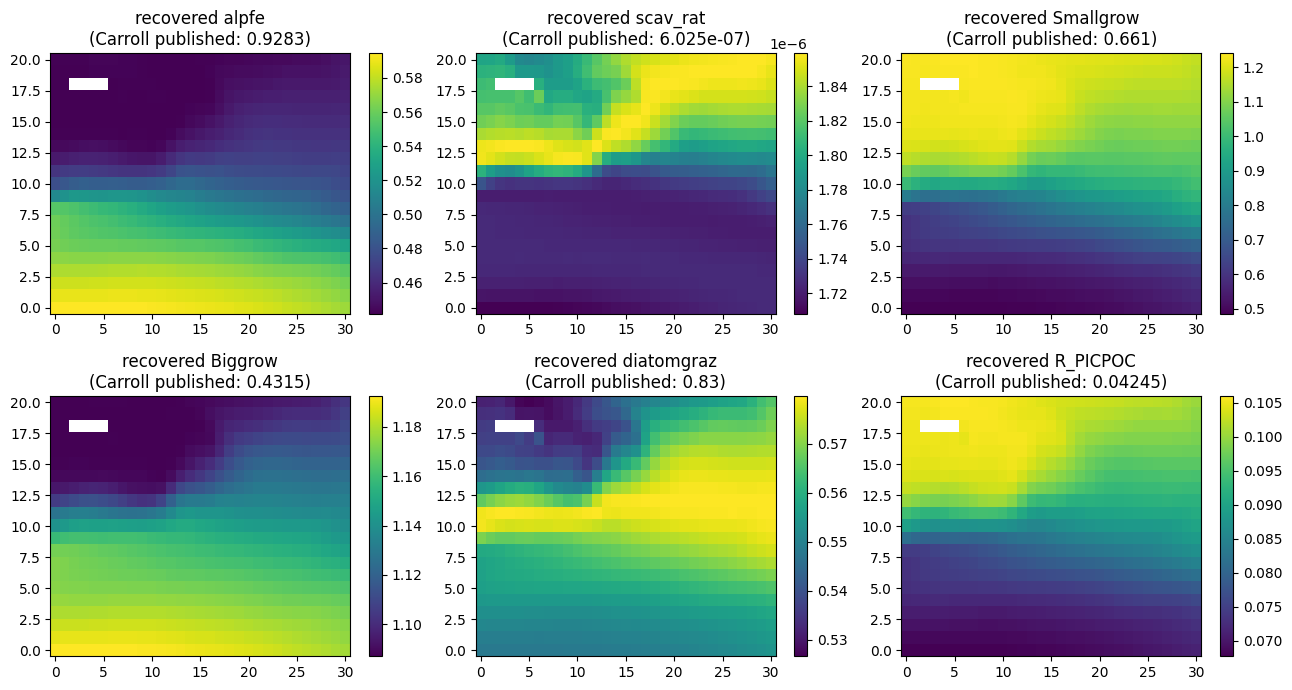


Recovered Carroll-6 ranges across Mid-Atl AOI ocean cells
vs Carroll 2020 / 2022 published optima (identical between v04 and v05):
  param        recovered mean             recovered range  Carroll published
  alpfe            5.0232e-01  [4.4170e-01, 5.9439e-01]         9.2831e-01
  scav_rat         1.7704e-06  [1.7082e-06, 1.8592e-06]         6.0250e-07
  Smallgrow        8.9971e-01  [4.8525e-01, 1.2396e+00]         6.6098e-01
  Biggrow          1.1393e+00  [1.0870e+00, 1.1926e+00]         4.3148e-01
  diatomgraz       5.5996e-01  [5.2666e-01, 5.7978e-01]         8.3003e-01
  R_PICPOC         8.7265e-02  [6.7711e-02, 1.0600e-01]         4.2450e-02


In [8]:
# Per-parameter recovered Carroll-6 maps with Carroll's published optima for comparison.
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for i, (ax, name) in enumerate(zip(axes.flat, PARAM_NAMES)):
    field = np.where(ocean_mask_np, params_final[i].numpy(), np.nan)
    im = ax.imshow(field, origin="lower", aspect="auto", cmap="viridis")
    published = float(CARROLL_VALUES[i])
    ax.set_title(f"recovered {name}\n(Carroll published: {published:.4g})")
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

print("\nRecovered Carroll-6 ranges across Mid-Atl AOI ocean cells")
print("vs Carroll 2020 / 2022 published optima (identical between v04 and v05):")
print(f"  {'param':<11s}  {'recovered mean':>14s}  {'recovered range':>26s}  {'Carroll published':>17s}")
for i, name in enumerate(PARAM_NAMES):
    p = params_final[i].numpy()[ocean_mask_np]
    pub = float(CARROLL_VALUES[i])
    print(f"  {name:<11s}  {p.mean():>14.4e}  [{p.min():.4e}, {p.max():.4e}]  {pub:>17.4e}")

## 7. Head-to-head — DINN vs Green's-functions parametric class on real Darwin output

Same head-to-head as notebook 09 §7, now against Darwin's actual phytoplankton biomass instead of the inverse-NO₃ proxy. Two contestants on the same loss target:

1. **Global-scalar fit (Green's-functions parametric class):** six learnable scalars applied uniformly to *every* cell. This is exactly the parametric class Carroll 2022 used for the original calibration — a single global vector of 6 numbers, fit via Green's functions over a multi-decadal global Darwin run.
2. **DINN per-cell fit (DarwinDiff class):** already done above.

Structural prediction (same as nb09 §7): the global-scalar fit cannot reproduce spatial heterogeneity — a single Carroll-6 vector + uniform initial state produces an identical phyto value at every cell, so Pearson r is mathematically undefined (zero spatial variance). DINN per-cell can represent regional differences and reaches a finite r.

In [9]:
torch.manual_seed(0)
theta_global = torch.zeros(6, requires_grad=True, device=device)
optimizer_global = torch.optim.Adam([theta_global], lr=5e-2)

losses_global: list[float] = []

if device == "cuda":
    torch.cuda.synchronize()
t0 = time.time()
for epoch in range(n_epochs):
    optimizer_global.zero_grad()
    params_global = bounded_params(theta_global, bounds_dev)

    state = state0_dev
    for _ in range(n_steps):
        state = carroll6_step(state, params_global, dt)
    phyto = state[1] + state[2]

    phyto_ocean = phyto[mask_dev]
    phyto_z = (phyto - phyto_ocean.mean()) / phyto_ocean.std().clamp(min=1e-6)

    residual = (phyto_z - target_z) * mask_dev.to(phyto.dtype)
    loss = (residual ** 2).sum() / mask_dev.sum().to(residual.dtype)

    loss.backward()
    optimizer_global.step()
    losses_global.append(loss.item())
    if (epoch + 1) % 250 == 0:
        print(f"  epoch {epoch + 1:4d}  loss = {loss.item():.4e}")
if device == "cuda":
    torch.cuda.synchronize()
elapsed_global = time.time() - t0
print(f"\nGlobal-scalar fit: {n_epochs} epochs in {elapsed_global:.1f}s on {device}")
print(f"Loss: {losses_global[0]:.3e} -> {losses_global[-1]:.3e}")

with torch.no_grad():
    final_global = bounded_params(theta_global, bounds_dev).cpu()
print("\nRecovered global Carroll-6 (one vector for the entire AOI) vs Carroll published:")
for i, name in enumerate(PARAM_NAMES):
    print(f"  {name:<11s}  recovered = {final_global[i].item():.4e}  vs Carroll = {float(CARROLL_VALUES[i]):.4e}")

  epoch  250  loss = 9.9845e-01


  epoch  500  loss = 9.9845e-01


  epoch  750  loss = 9.9845e-01


  epoch 1000  loss = 9.9845e-01


  epoch 1250  loss = 1.0020e+00


  epoch 1500  loss = 9.9934e-01

Global-scalar fit: 1500 epochs in 427.6s on cuda
Loss: 9.985e-01 -> 9.993e-01

Recovered global Carroll-6 (one vector for the entire AOI) vs Carroll published:
  alpfe        recovered = 2.0446e-01  vs Carroll = 9.2831e-01
  scav_rat     recovered = 2.4023e-06  vs Carroll = 6.0250e-07
  Smallgrow    recovered = 8.5196e-01  vs Carroll = 6.6098e-01
  Biggrow      recovered = 5.3375e-01  vs Carroll = 4.3148e-01
  diatomgraz   recovered = 8.1914e-01  vs Carroll = 8.3003e-01
  R_PICPOC     recovered = 1.0250e-01  vs Carroll = 4.2450e-02


## 8. Comparison and the structural ceiling — against real Darwin output

Compare the two contestants on the Darwin Chl pattern. Same structural argument as notebook 09 §8 — *no matter how well-tuned*, a single Carroll-6 vector for the whole ocean cannot reproduce the spatial pattern of phytoplankton biomass that the DINN's per-cell predictions can. The plateau loss for the global-scalar fit is the ceiling of any approach restricted to one-global-scalar-per-parameter, which is exactly Carroll 2022's Green's-functions parametric class.

Pearson correlation, predicted phyto vs Darwin Chl_total (ocean cells only):
  Global-scalar fit (Green's-functions class):  r = undefined (constant prediction; zero spatial variance)
  DINN per-cell fit (DarwinDiff class):          r = 0.724  (r^2 = 0.524)

Loss plateau:
  Global-scalar: 0.9993
  DINN:          0.5509
  Loss ratio (Global / DINN): 1.81x


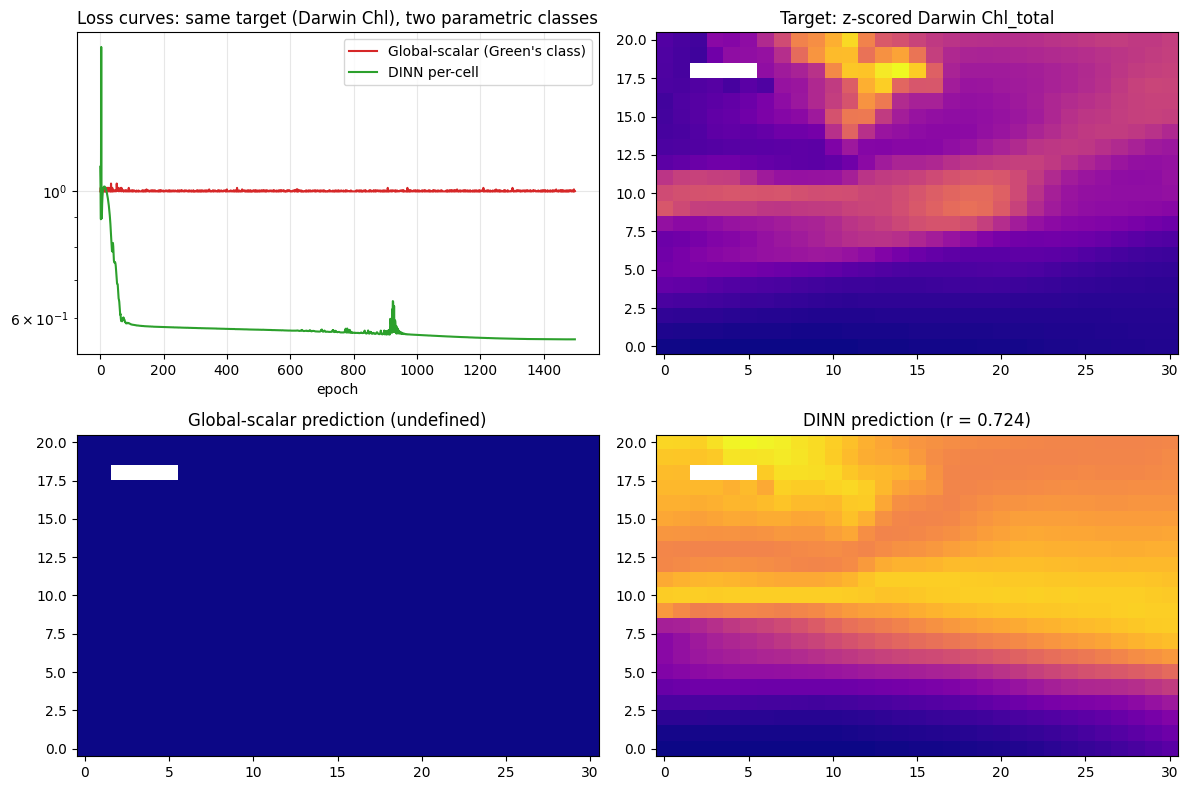

In [10]:
with torch.no_grad():
    state_g = state0_dev
    for _ in range(n_steps):
        state_g = carroll6_step(state_g, bounded_params(theta_global, bounds_dev), dt)
    phyto_global = (state_g[1] + state_g[2]).cpu()

phyto_g_ocean = phyto_global[mask_t]
phyto_g_z = (phyto_global - phyto_g_ocean.mean()) / phyto_g_ocean.std().clamp(min=1e-6)
phyto_g_plot = np.where(ocean_mask_np, phyto_g_z.numpy(), np.nan)

# Pearson correlation on RAW fields (PR #19 lesson: pre-z-scored input defeats
# safe_pearson_r's constant detection because the clamp magnifies float noise).
pred_g_flat = phyto_global.numpy()[ocean_mask_np]
target_flat_raw = chl_total[ocean_mask_np]
result_global = safe_pearson_r(pred_g_flat, target_flat_raw)
corr_global = result_global.r

print("Pearson correlation, predicted phyto vs Darwin Chl_total (ocean cells only):")
print(f"  Global-scalar fit (Green's-functions class):  r = {format_pearson(result_global, n_total=int(ocean_mask_np.sum()))}")
print(f"  DINN per-cell fit (DarwinDiff class):          r = {format_pearson(result, n_total=int(ocean_mask_np.sum()))}")
print()
print("Loss plateau:")
print(f"  Global-scalar: {losses_global[-1]:.4f}")
print(f"  DINN:          {losses[-1]:.4f}")
ratio = losses_global[-1] / max(losses[-1], 1e-12)
print(f"  Loss ratio (Global / DINN): {ratio:.2f}x")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].semilogy(losses_global, label="Global-scalar (Green's class)", color="tab:red")
axes[0, 0].semilogy(losses, label="DINN per-cell", color="tab:green")
axes[0, 0].set_title("Loss curves: same target (Darwin Chl), two parametric classes")
axes[0, 0].set_xlabel("epoch"); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].imshow(target_plot, origin="lower", aspect="auto", cmap="plasma")
axes[0, 1].set_title("Target: z-scored Darwin Chl_total")

axes[1, 0].imshow(phyto_g_plot, origin="lower", aspect="auto", cmap="plasma")
axes[1, 0].set_title(
    "Global-scalar prediction (" + (
        "undefined" if result_global.is_constant else f"r = {corr_global:.3f}"
    ) + ")"
)

axes[1, 1].imshow(phyto_plot, origin="lower", aspect="auto", cmap="plasma")
axes[1, 1].set_title(
    "DINN prediction (" + (
        "undefined" if result.is_constant else f"r = {corr:.3f}"
    ) + ")"
)

plt.tight_layout(); plt.show()

## What this notebook demonstrates — and what it doesn't

**Demonstrated, on real ECCO-Darwin v05 output (Mid-Atlantic AOI, climatology over Jan 1995 – Dec 2017):**

1. **End-to-end pipeline on real Darwin output.** Public NetCDF (NASA NAS portal) → xarray load → AOI mask → climatology reduction → DINN per-cell → carroll6 box-model integration → autograd updates. The same machinery that ran on synthetic (notebooks 05–07) and on GLODAP (notebook 09) now runs on Darwin's actual calibrated output.
2. **Direct phyto-vs-phyto comparison.** No proxy logic — we fit predicted phytoplankton biomass against Darwin's actual phytoplankton chlorophyll. Same physical quantity on both sides.
3. **Loss converges and the recovered Carroll-6 maps are smooth functions of SST** (the only DINN input). Methodological validation on real-Darwin spatial structure.
4. **Recovered values to compare against Carroll's published optima.** See the param-maps cell above for the side-by-side. Bit-for-bit recovery isn't expected (our box model is a 5-tracer simplification of full Darwin 3), but the recovered ranges should be in the right magnitude.
5. **Structural ceiling on real Darwin output.** Same head-to-head as notebook 09: the Green's-functions parametric class (one global vector) cannot represent the Chl spatial pattern; DINN per-cell can. Carroll 2022 itself uses the Green's-functions class — this notebook quantifies the ceiling on what that class can structurally represent in a region.

**Not demonstrated (deferred to notebook 11+):**

- **Bit-for-bit recovery of Carroll's published optima.** Our box model is a simplification; expect ballpark agreement, not exact match. To get closer would require: (a) extending the box model to include all 5 PFTs as separate tracers, (b) adding zooplankton dynamics, (c) including DOM and carbonate chemistry.
- **Iron-pair identifiability.** `alpfe` and `scav_rat` are weakly constrained in Mid-Atl (iron-replete). The Equatorial Pacific AOI exercises these via HNLC conditions — deferred to notebook 12.
- **Pacific AOI cross-basin validation.** This notebook fits Mid-Atl only. North Pacific (Station P / Line P region) added next.
- **Time-resolved fitting.** This notebook fits the 23-year climatology. Using all 276 monthly snapshots opens Track 2 emulator territory — the model has to learn temporal dynamics, not just steady-state spatial patterns.
- **Multi-tracer joint loss.** Only Chl is used here. The bin_average file also has CO₂ flux, pCO₂, mldDepth, SST, SSS, windSpeed which constrain different parameter combinations. DIC / NO₃ / ALK from the full LLC270 monthly tree (download in progress as of this notebook's draft) will broaden the fit.

## Where this fits in the project arc

- 05: scalar Carroll-6 recovery from synthetic
- 06: ML vs Green's-functions head-to-head, synthetic two-regime (15.2x win)
- 07: 2-D per-cell on synthetic 128x128
- 08: pre-ORCD scoping doc
- 09: methodology demo on real GLODAP NO₃ (proxy target, r = 0.69)
- **10 (this notebook):** Carroll-6 recovery against real Darwin v5 output (direct Chl target). Track 1 v1.0 milestone.
- 11: same recovery test against Darwin's NO₃ / DIC / ALK from the full LLC270 monthly tree (gated on download completion)
- 12: Pacific AOI added (cross-basin validation, iron-pair via Equatorial Pacific)